# WineQT Classification using Machine Learning

### Nama : Yosua Dirgana Pratama  
### Mata Kuliah : Machine Learning  
### Dataset : WineQT Dataset  

---

## Deskripsi Praktikum

Pada praktikum ini dilakukan proses klasifikasi menggunakan dataset **WineQT**. Tahapan yang dilakukan meliputi eksplorasi data, preprocessing, visualisasi, pelatihan model, hingga evaluasi performa model machine learning.

---

## Tujuan

Praktikum ini bertujuan untuk:

- Memahami karakteristik dataset
- Melakukan preprocessing data
- Membuat visualisasi data
- Melatih model klasifikasi
- Mengevaluasi performa model

---

## Flow Sistem

Dataset WineQT

⬇

Exploratory Data Analysis

⬇

Preprocessing

⬇

Feature Selection

⬇

Training Model

⬇

Prediction

⬇

Evaluation

# Import Library

Tahap pertama adalah mengimpor library yang digunakan pada proses analisis dan klasifikasi data.

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# 1. Load Dataset

Pada tahap ini dataset akan dibaca menggunakan library **Pandas**.

Dataset yang digunakan adalah **WineQT.csv** yang berisi berbagai fitur numerik terkait karakteristik kimia pada wine seperti acidity, alcohol, sulphates, pH, chlorides, dan beberapa atribut lainnya.

Setelah dataset berhasil dibaca, beberapa baris pertama data akan ditampilkan untuk memastikan bahwa file berhasil dimuat dengan benar.

In [5]:
# Membaca dataset

df = pd.read_csv("WineQT.csv")

# Menampilkan 5 data pertama
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


# 2. Dataset Information

Sebelum melakukan clustering, penting untuk memahami struktur dataset terlebih dahulu.

Tahap ini dilakukan untuk melihat:

- Jumlah data dan jumlah fitur
- Nama setiap kolom
- Tipe data setiap variabel
- Statistik deskriptif dataset

Informasi ini membantu dalam memahami karakteristik data sebelum dilakukan preprocessing dan proses clustering.

In [7]:
print("Dataset Shape:", df.shape)

df.info()

df.describe()

Dataset Shape: (1143, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


# Statistik Deskriptif

Statistik deskriptif digunakan untuk melihat gambaran umum data secara numerik seperti nilai rata-rata, standar deviasi, nilai minimum, maksimum, dan kuartil.

Tahapan ini membantu memahami karakteristik distribusi data.

In [8]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


# 3. Missing Value Checking

Pengecekan missing value dilakukan untuk memastikan apakah terdapat data kosong atau nilai yang hilang pada dataset.

Keberadaan missing value dapat mempengaruhi performa model clustering, sehingga perlu dilakukan pemeriksaan terlebih dahulu sebelum masuk ke tahap preprocessing.

Apabila tidak ditemukan missing value, maka dataset dapat langsung digunakan pada proses berikutnya.

In [12]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

# 4. Data Distribution Visualization

Visualisasi distribusi data digunakan untuk memahami pola penyebaran masing-masing fitur numerik dalam dataset.

Melalui visualisasi ini, kita dapat melihat:

- Pola distribusi data
- Potensi outlier
- Rentang nilai tiap fitur
- Karakteristik awal dataset

Pemahaman distribusi data penting sebelum melakukan scaling dan clustering.

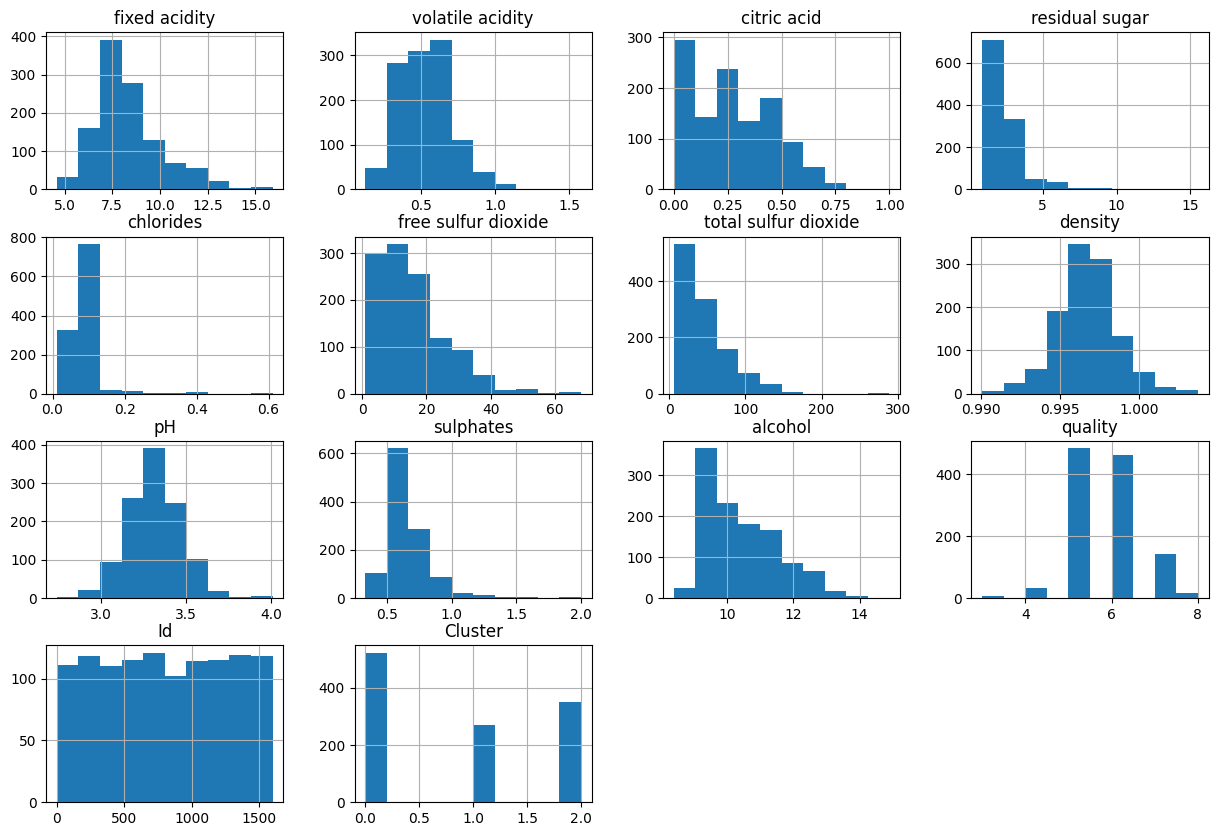

In [20]:
df.hist(
    figsize=(15,10)
)

plt.show()

# 5. Heatmap Korelasi

Heatmap digunakan untuk melihat hubungan antar fitur pada dataset. Nilai korelasi yang tinggi menunjukkan adanya hubungan yang kuat antar variabel.

Visualisasi ini dapat membantu proses analisis fitur.

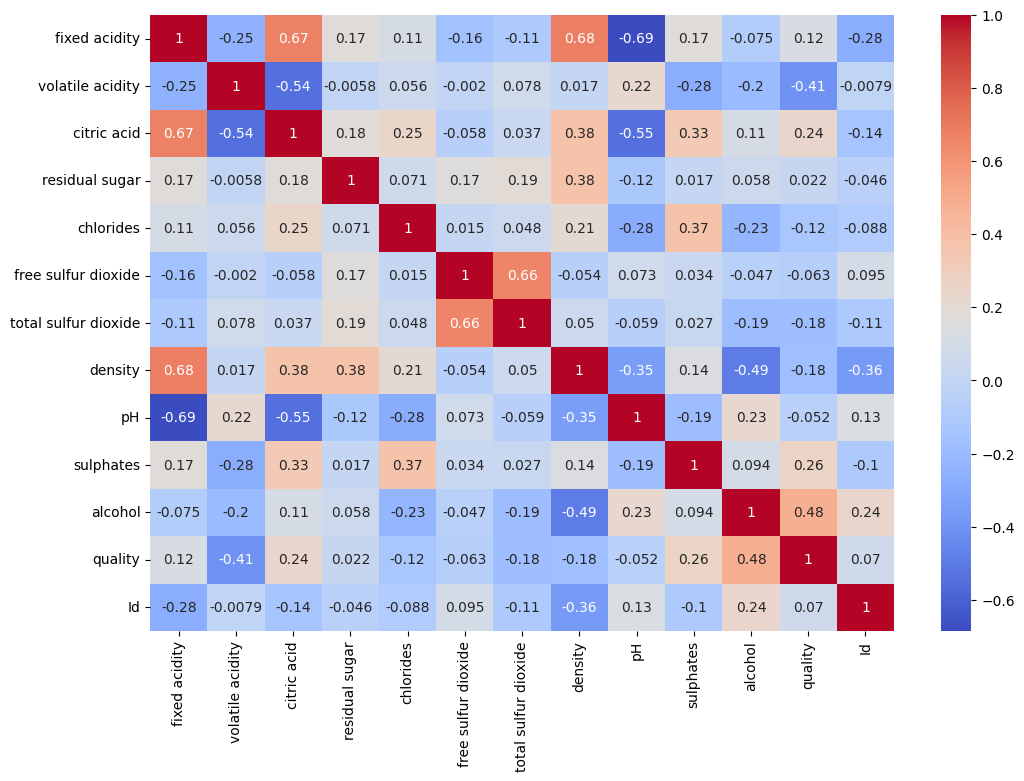

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(
df.corr(),
annot=True,
cmap='coolwarm'
)

plt.show()

# 6. Feature Selection

Pada proses clustering menggunakan KMeans, hanya fitur numerik yang relevan akan digunakan.

Kolom **Id** tidak digunakan karena hanya berfungsi sebagai identitas data.

Kolom **quality** juga tidak digunakan dalam proses clustering karena KMeans termasuk metode **unsupervised learning**, sehingga model tidak memerlukan label target untuk melakukan pengelompokan data.

Fitur yang tersisa akan digunakan sebagai input model clustering.

In [21]:
X = df.drop(
    ['Id','quality'],
    axis=1
)

X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,2
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


# 7. Data Scaling

Algoritma KMeans sangat sensitif terhadap perbedaan skala data.

Jika terdapat fitur dengan rentang nilai yang jauh berbeda, maka fitur tersebut dapat mendominasi proses pembentukan cluster.

Oleh karena itu dilakukan proses **standardization** menggunakan **StandardScaler** agar setiap fitur memiliki skala yang relatif sama dengan mean mendekati 0 dan standar deviasi mendekati 1.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# 8. Elbow Method

Salah satu langkah penting pada KMeans adalah menentukan jumlah cluster optimal.

Pada notebook ini digunakan **Elbow Method** untuk menentukan nilai K terbaik.

Metode ini bekerja dengan menghitung **WCSS (Within Cluster Sum of Squares)** pada beberapa jumlah cluster.

Nilai WCSS kemudian diplot ke dalam grafik untuk mencari titik "siku" atau **elbow point** yang menunjukkan jumlah cluster optimal.

In [15]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

C:\Users\Yosua Dirgana\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\Yosua Dirgana\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\Yosua Dirgana\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\Yosua Dirgana\AppData\Roaming\Python\Python313

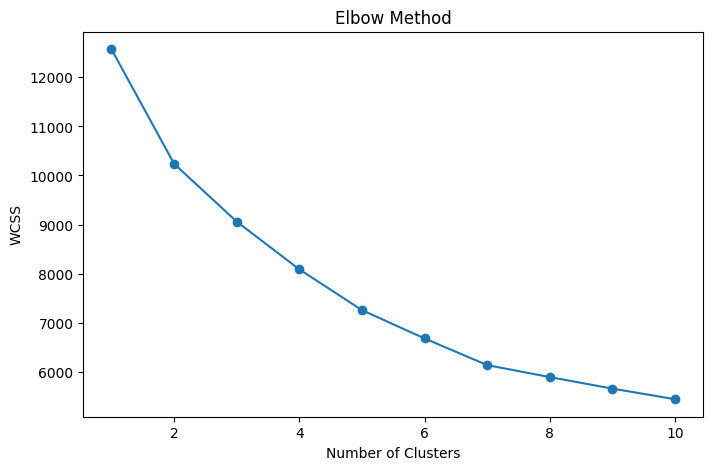

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel('Number of Clusters')

plt.ylabel('WCSS')

plt.title('Elbow Method')

plt.show()

# 9. KMeans Model Training

Setelah jumlah cluster optimal diperoleh dari Elbow Method, model KMeans dapat dijalankan.

Pada contoh ini digunakan **3 cluster** sebagai jumlah cluster yang dipilih.

Model akan mengelompokkan data berdasarkan kemiripan karakteristik antar observasi.

In [23]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    X_scaled
)

C:\Users\Yosua Dirgana\AppData\Roaming\Python\Python313\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


# 10. Add Cluster Result

Setelah proses clustering selesai dilakukan, hasil cluster akan ditambahkan ke dalam dataset.

Penambahan kolom cluster mempermudah analisis terhadap hasil pengelompokan data yang telah dibentuk oleh model KMeans.

In [24]:
df['Cluster'] = clusters

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,Cluster
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,2
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0


# 11. PCA Cluster Visualization

Dataset memiliki banyak fitur numerik sehingga cukup sulit divisualisasikan secara langsung.

Oleh karena itu digunakan **Principal Component Analysis (PCA)** untuk mereduksi dimensi data menjadi dua komponen utama.

Visualisasi PCA memungkinkan kita untuk melihat pola cluster yang dihasilkan oleh model KMeans dalam bentuk grafik dua dimensi.

In [25]:
from sklearn.decomposition import PCA

In [26]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

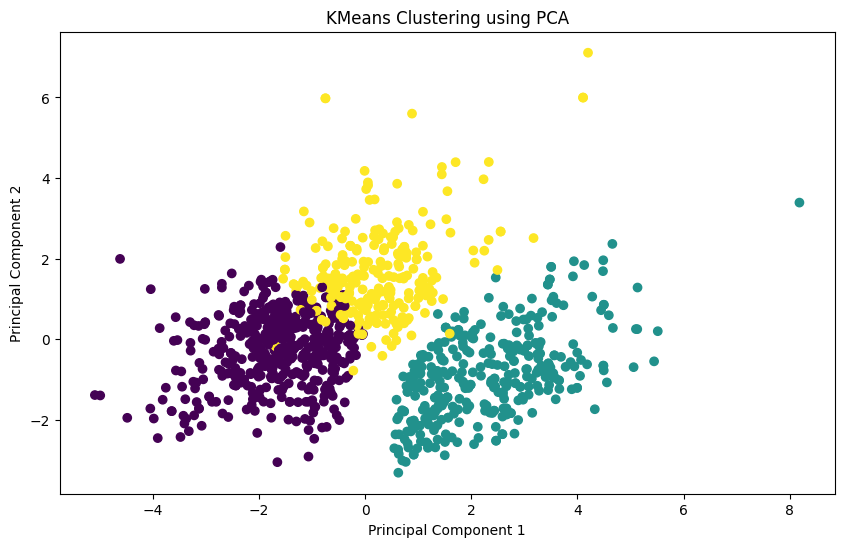

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis'
)

plt.xlabel(
    'Principal Component 1'
)

plt.ylabel(
    'Principal Component 2'
)

plt.title(
    'KMeans Clustering using PCA'
)

plt.show()

# 12. Model Evaluation

Evaluasi clustering dilakukan menggunakan **Silhouette Score**.

Silhouette Score digunakan untuk mengukur kualitas hasil clustering berdasarkan tingkat kemiripan data di dalam cluster yang sama dibandingkan dengan cluster lain.

Semakin tinggi nilai Silhouette Score, maka kualitas clustering umumnya semakin baik.

In [28]:
from sklearn.metrics import silhouette_score

In [29]:
score = silhouette_score(
    X_scaled,
    clusters
)

print(
    "Silhouette Score :",
    score
)

Silhouette Score : 0.23139456319864377


# 13. Conclusion

Pada notebook ini telah dilakukan implementasi algoritma **KMeans Clustering** pada dataset **Wine Quality Dataset**.

Tahapan preprocessing dilakukan melalui feature selection dan data scaling sebelum model dilatih.

Jumlah cluster ditentukan menggunakan **Elbow Method**, kemudian hasil clustering divisualisasikan menggunakan **PCA Visualization**.

Berdasarkan hasil evaluasi menggunakan **Silhouette Score**, dapat dilakukan analisis terhadap kualitas cluster yang dihasilkan oleh model.

Implementasi ini menunjukkan bahwa algoritma KMeans dapat digunakan untuk menemukan pola pengelompokan data berdasarkan karakteristik kimia pada dataset wine.